# Cruzamento Espacial do Voto (VAA) - Perfil Individual

Neste notebook, aplicamos a Teoria Espacial do Voto de Anthony Downs (1957) para um **único eleitor**.
Você insere as respostas do eleitor e o algoritmo mapeia a proximidade dele com os pré-candidatos, gerando a recomendação (Bússola Eleitoral) baseada na distância matemática e na similaridade de perfil.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.decomposition import PCA
import ipywidgets as widgets
from IPython.display import display, HTML

sns.set_theme(style='whitegrid')

## 1. O Perfil dos Pré-Candidatos (Gabarito)
Convertemos as posições públicas de candidatos em coordenadas nos nossos blocos D (Economia) e E (Valores).

In [2]:
candidatos_data = {
    'Candidato': ['Lula', 'Flavio Bolsonaro', 'Romeu Zema', 'Ciro Gomes'],
    'bloco_d_estatais': [1, 5, 5, 2],    # 1=Discorda(Estado forte), 5=Concorda(Privatização)
    'bloco_d_tabelamento': [4, 1, 1, 3], # 1=Livre Mercado, 5=Intervenção Estatal
    'bloco_e_punitivismo': [2, 5, 4, 3], # 1=Garantismo, 5=Punitivismo
    'bloco_e_educacao': [2, 5, 4, 2]     # 1=Progressista, 5=Conservador
}
df_candidatos = pd.DataFrame(candidatos_data).set_index('Candidato')
display(df_candidatos)

,bloco_d_estatais,bloco_d_tabelamento,bloco_e_punitivismo,bloco_e_educacao
Candidato,,,,
Lula,1,4,2,2
Flavio Bolsonaro,5,1,5,5
Romeu Zema,5,1,4,4
Ciro Gomes,2,3,3,2


## 2. Formulário Interativo do Eleitor
Preencha o formulário completo (Blocos A a F) para definir o perfil sociodemográfico e ideológico do eleitor.

In [3]:
# Criação dos widgets interativos
style = {'description_width': 'initial'}

nome_widget = widgets.Text(value='Eleitor Exemplo', description='Nome:', style=style)

display(HTML('<h3>Bloco A - Demografia e Clivagens Sociais</h3>'))
idade_widget = widgets.IntText(value=30, description='Idade:', style=style)
renda_widget = widgets.Dropdown(options=['Até 2 salários mínimos', '2 a 5 salários mínimos', 'Mais de 5 salários mínimos'], description='Faixa de Renda:', style=style)
escolaridade_widget = widgets.Dropdown(options=['Ensino Fundamental', 'Ensino Médio', 'Ensino Superior'], description='Escolaridade:', style=style)
regiao_widget = widgets.Dropdown(options=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'], description='Região:', style=style)
religiao_widget = widgets.Dropdown(options=['Católica', 'Evangélica', 'Outra', 'Sem Religião'], description='Religião:', style=style)
beneficio_widget = widgets.Dropdown(options=['Sim', 'Não'], description='Recebe Benefício Social?', style=style)

display(HTML('<h3>Bloco B - Capital Cultural</h3>'))
informacao_widget = widgets.Dropdown(options=['TV Aberta', 'Redes Sociais (Instagram/TikTok)', 'Aplicativos de Mensagem (WhatsApp/Telegram)', 'Mídia Independente', 'Rádio'], description='Principal Fonte de Informação:', style=style)

display(HTML('<h3>Bloco C - Matriz de Valores</h3>'))
prioridade_widget = widgets.Dropdown(options=['Controle da Inflação', 'Geração de Empregos', 'Combate ao Crime Violento', 'Preservação Ambiental', 'Combate às Desigualdades', 'Defesa da Família Tradicional', 'Liberdade de Expressão'], description='Prioridade Absoluta:', style=style)

display(HTML('<h3>Bloco D - Economia (Eixo X)</h3>'))
estatais_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Privatização de Estatais (1=Estado Forte, 5=Privatização Total):',
    style=style, layout=widgets.Layout(width='80%')
)
tabelamento_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Controle de Preços (1=Livre Mercado, 5=Intervenção Estatal):',
    style=style, layout=widgets.Layout(width='80%')
)

display(HTML('<h3>Bloco E - Valores e Moral (Eixo Y)</h3>'))
punitivismo_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Segurança Pública (1=Ressocialização, 5=Punição Severa):',
    style=style, layout=widgets.Layout(width='80%')
)
educacao_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Educação (1=Progressista, 5=Conservadora):',
    style=style, layout=widgets.Layout(width='80%')
)

display(HTML('<h3>Bloco F - Decisão e Polarização</h3>'))
opcoes_rejeicao = ['Nenhum'] + list(df_candidatos.index)
rejeicao_widget = widgets.Dropdown(
    options=opcoes_rejeicao,
    value='Nenhum',
    description='Rejeição Absoluta (Não votaria de jeito nenhum):',
    style=style, layout=widgets.Layout(width='50%')
)

# Agrupando e exibindo o formulário completo
form = widgets.VBox([
    nome_widget, widgets.HTML('<hr>'),
    idade_widget, renda_widget, escolaridade_widget, regiao_widget, religiao_widget, beneficio_widget, widgets.HTML('<hr>'),
    informacao_widget, widgets.HTML('<hr>'),
    prioridade_widget, widgets.HTML('<hr>'),
    estatais_widget, tabelamento_widget, widgets.HTML('<hr>'),
    punitivismo_widget, educacao_widget, widgets.HTML('<hr>'),
    rejeicao_widget
])
display(form)

## 3. O Motor VAA: Calculando Proximidade e Afastamento
O algoritmo captura as respostas do formulário acima, calcula a Distância Euclidiana baseada nas coordenadas ideológicas e aplica a penalidade caso exista Rejeição Absoluta.

*Execute esta célula APÓS preencher o formulário acima.*

In [4]:
# Lendo os valores do formulário interativo
eleitor_nome = nome_widget.value
estatais = estatais_widget.value
tabelamento = tabelamento_widget.value
punitivismo = punitivismo_widget.value
educacao = educacao_widget.value
rejeicao_absoluta = rejeicao_widget.value

vetor_eleitor = np.array([[estatais, tabelamento, punitivismo, educacao]])
print(f"Perfil capturado do Eleitor '{eleitor_nome}': {vetor_eleitor[0]}\n")

print(f"Demografia: {idade_widget.value} anos, {regiao_widget.value}, {renda_widget.value}, Benefício: {beneficio_widget.value}")
print(f"Valores: {prioridade_widget.value} | Informação: {informacao_widget.value}\n")

vetores_candidatos = df_candidatos.values

# --- Distância Euclidiana ---
# Quanto MENOR, mais próximo o eleitor está do candidato nas suas opiniões.
dist_euclidiana = euclidean_distances(vetor_eleitor, vetores_candidatos)[0]

resultados = pd.DataFrame({
    'Candidato': df_candidatos.index,
    'Distancia_Euclidiana': dist_euclidiana
})

# Aplicar filtro de Veto por Polarização Afetiva (Rejeição Absoluta)
resultados['Veto_Aplicado'] = resultados['Candidato'].apply(lambda x: True if x == rejeicao_absoluta else False)
resultados.loc[resultados['Veto_Aplicado'] == True, 'Distancia_Euclidiana'] = np.inf # Penalidade infinita

# Ordenar pelo mais próximo (menor distância)
resultados = resultados.sort_values(by='Distancia_Euclidiana').reset_index(drop=True)

print(f">>> RESULTADO DA BÚSSOLA ELEITORAL PARA: {eleitor_nome} <<<")
display(resultados)

cand_ideal = resultados.iloc[0]['Candidato']
if resultados.iloc[0]['Distancia_Euclidiana'] == np.inf:
    print("\nO eleitor rejeitou absolutamente todos os candidatos ou ocorreu um erro no cálculo.")
else:
    print(f"\nO candidato com maior alinhamento técnico às respostas é: **{cand_ideal}**")

Perfil capturado do Eleitor 'Eleitor Exemplo': [3 3 3 3]

Demografia: 30 anos, Norte, Até 2 salários mínimos, Benefício: Sim
Valores: Controle da Inflação | Informação: TV Aberta

>>> RESULTADO DA BÚSSOLA ELEITORAL PARA: Eleitor Exemplo <<<


,Candidato,Distancia_Euclidiana,Veto_Aplicado
0,Ciro Gomes,1.414214,False
1,Lula,2.645751,False
2,Romeu Zema,3.162278,False
3,Flavio Bolsonaro,4.000000,False



O candidato com maior alinhamento técnico às respostas é: **Ciro Gomes**


## 4. Visualização 2D (Bússola Eleitoral)
Comprimimos as 4 dimensões de opiniões em 2 usando PCA para que possamos enxergar a posição do eleitor no mapa político.

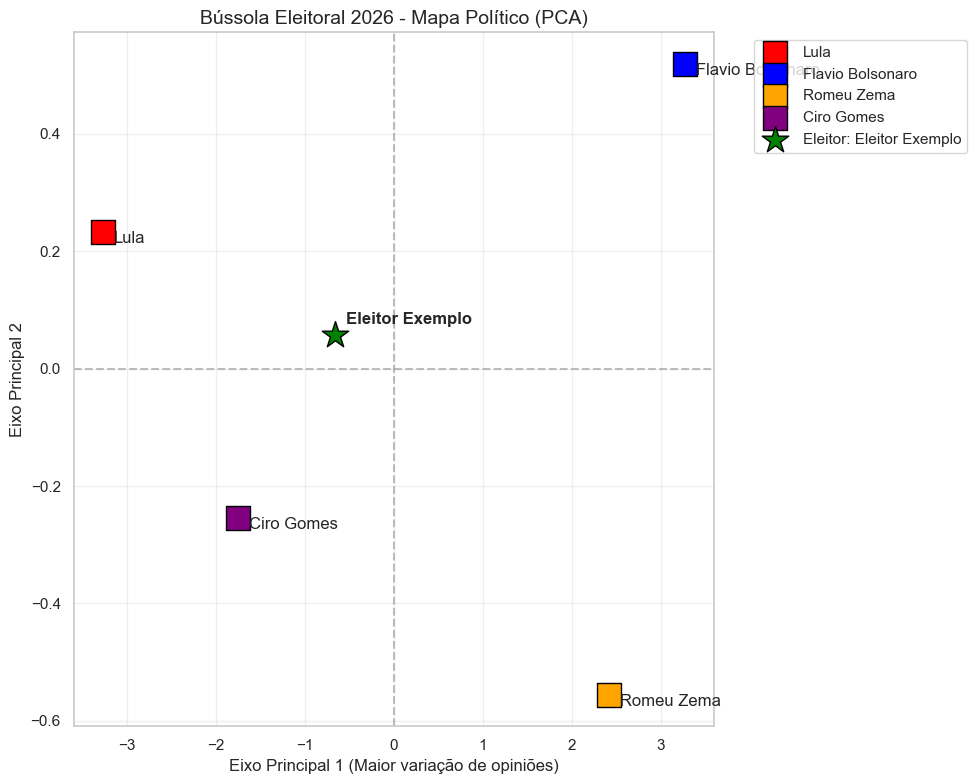

In [5]:
pca = PCA(n_components=2)

# Juntar o eleitor com os candidatos para o mapa
vetores_totais = np.vstack([df_candidatos.values, vetor_eleitor])
proj_2d = pca.fit_transform(vetores_totais)

proj_cand = proj_2d[:len(df_candidatos)]
proj_eleit = proj_2d[-1] # Último é o eleitor

plt.figure(figsize=(10, 8))

# Plotar candidatos
cores_cand = ['red', 'blue', 'orange', 'purple']
for i, (idx, row) in enumerate(df_candidatos.iterrows()):
    plt.scatter(proj_cand[i, 0], proj_cand[i, 1], color=cores_cand[i], s=300, edgecolors='black', label=idx, marker='s')
    plt.annotate(idx, (proj_cand[i, 0], proj_cand[i, 1]), xytext=(8, -8), textcoords='offset points')

# Plotar o Eleitor
plt.scatter(proj_eleit[0], proj_eleit[1], color='green', s=400, edgecolors='black', label=f"Eleitor: {eleitor_nome}", marker='*')
plt.annotate(f"{eleitor_nome}", (proj_eleit[0], proj_eleit[1]), xytext=(8, 8), textcoords='offset points', fontweight='bold')

plt.title(f'Bússola Eleitoral 2026 - Mapa Político (PCA)', fontsize=14)
plt.xlabel('Eixo Principal 1 (Maior variação de opiniões)')
plt.ylabel('Eixo Principal 2')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()